In [69]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [119]:
data = yf.download("SBIN.NS", start="2020-01-01", end="2024-01-01")
print(data.head())

C:\Users\Nandini\AppData\Local\Temp\ipykernel_22492\1816524099.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("SBIN.NS", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker         SBIN.NS     SBIN.NS     SBIN.NS     SBIN.NS   SBIN.NS
Date                                                                
2020-01-01  303.138489  304.498057  301.053800  303.365084  17379320
2020-01-02  307.534363  308.032888  302.141425  303.183755  20324236
2020-01-03  302.458740  306.310852  300.917885  306.310852  21853208
2020-01-06  289.134918  300.645943  287.956637  300.645943  35645325
2020-01-07  288.591064  296.385929  285.871927  294.074674  50966826


In [120]:
data.columns = data.columns.get_level_values(0)

In [121]:
data = data[["Open","High", "Low","Close","Volume"]]


In [122]:
data['SMA20'] = data['Close'].rolling(20).mean()
data['SMA50'] = data['Close'].rolling(50).mean()
data['AvgVol20'] = data['Volume'].rolling(20).mean()

C:\Users\Nandini\AppData\Local\Temp\ipykernel_22492\2328954778.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['SMA20'] = data['Close'].rolling(20).mean()
C:\Users\Nandini\AppData\Local\Temp\ipykernel_22492\2328954778.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['SMA50'] = data['Close'].rolling(50).mean()
C:\Users\Nandini\AppData\Local\Temp\ipykernel_22492\2328954778.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [123]:
data['Signal'] = 0

# Buy: bullish crossover + volume confirmation
buy_condition = (
    (data['SMA20'] > data['SMA50']) &
    (data['SMA20'].shift(1) <= data['SMA50'].shift(1)) &
    (data['Volume'] > data['AvgVol20'])
)

# Sell: bearish crossover
sell_condition = (
    (data['SMA20'] < data['SMA50']) &
    (data['SMA20'].shift(1) >= data['SMA50'].shift(1))
)

data.loc[buy_condition, 'Signal'] = 1
data.loc[sell_condition, 'Signal'] = -1
data['Signal'] = data['Signal'].shift(1)

C:\Users\Nandini\AppData\Local\Temp\ipykernel_22492\3164240773.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Signal'] = 0
C:\Users\Nandini\AppData\Local\Temp\ipykernel_22492\3164240773.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Signal'] = data['Signal'].shift(1)


In [124]:
initial_capital = 100000
cash = initial_capital
shares = 0
position = 0   # 0 = no stock, 1 = holding stock
portfolio_values = []

for i in range(len(data)):
    signal = data['Signal'].iloc[i]
    price = data['Close'].iloc[i]

    # Buy only if not already holding
    if signal == 1 and position == 0:
        shares = cash // price
        cash -= shares * price
        position = 1

    # Sell only if holding
    elif signal == -1 and position == 1:
        cash += shares * price
        shares = 0
        position = 0

    portfolio_value = cash + shares * price
    portfolio_values.append(portfolio_value)

data['Portfolio_Value'] = portfolio_values


C:\Users\Nandini\AppData\Local\Temp\ipykernel_22492\79657055.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Portfolio_Value'] = portfolio_values


In [125]:
final_value = data['Portfolio_Value'].iloc[-1]
profit = final_value - initial_capital
return_pct = (profit / initial_capital) * 100

print(f"Initial Capital: {initial_capital:.2f}")
print(f"Final Portfolio Value: {final_value:.2f}")
print(f"Net Profit: {profit:.2f}")
print(f"Return: {return_pct:.2f}%")


Initial Capital: 100000.00
Final Portfolio Value: 154057.59
Net Profit: 54057.59
Return: 54.06%


In [126]:
strategy_return =  return_pct
market_return = ((data['Close'].iloc[-1] / data['Close'].iloc[0]) - 1) * 100
print(f"Market Return = {market_return:.2f}% | Strategy Return = {strategy_return:.2f}%")

Market Return = 100.59% | Strategy Return = 54.06%


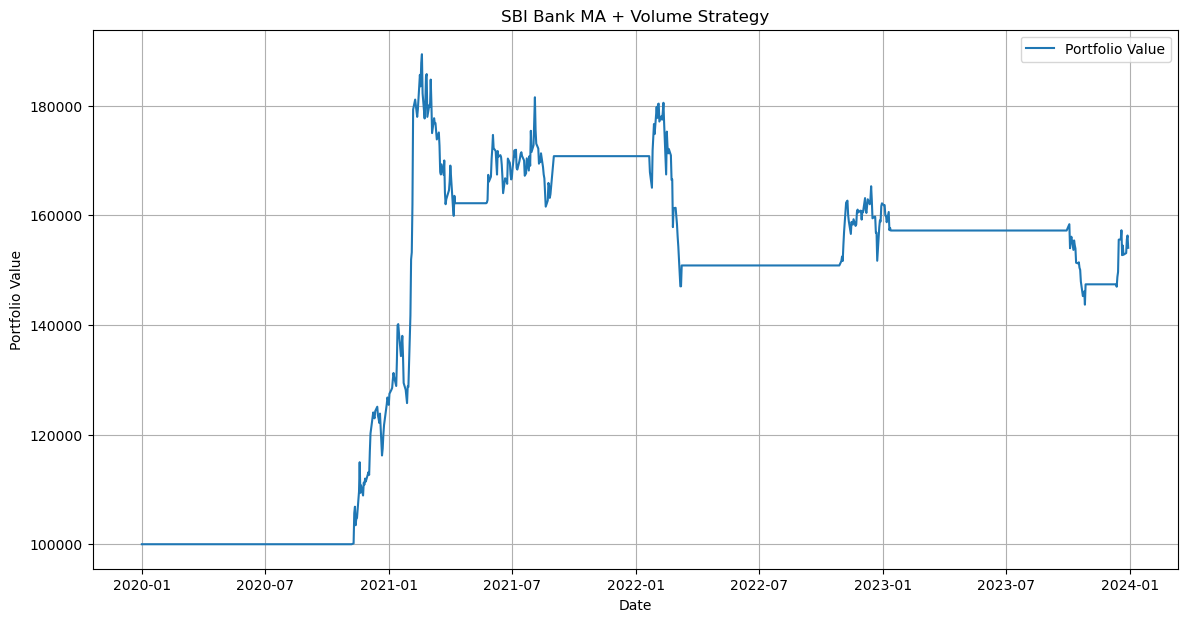

In [131]:
plt.figure(figsize=(14,7))
plt.plot(data.index, data['Portfolio_Value'], label='Portfolio Value')
plt.title("SBI Bank MA + Volume Strategy")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()

In [128]:
trade_count = 0

for i in range(len(data)):
    signal = data['Signal'].iloc[i]
    price = data['Close'].iloc[i]

    if signal == 1 and position == 0:
        shares = cash // price
        cash -= shares * price
        position = 1
        trade_count += 1

    elif signal == -1 and position == 1:
        cash += shares * price
        shares = 0
        position = 0
        trade_count += 1


print("Executed Trades:", trade_count)

Executed Trades: 12


In [129]:
data['Daily_Return'] = data['Portfolio_Value'].pct_change()

C:\Users\Nandini\AppData\Local\Temp\ipykernel_22492\4233603059.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Daily_Return'] = data['Portfolio_Value'].pct_change()


In [130]:
sharpe_ratio = (data['Daily_Return'].mean()/data['Daily_Return'].std()) * (252 ** 0.5)

rolling_max = data['Portfolio_Value'].cummax()
drawdown = (data['Portfolio_Value'] - rolling_max)/ rolling_max
max_drawdown = drawdown.min() * 100

print("Sharpe Ratio:", round(sharpe_ratio, 2))
print("Max Drawdown:", round(max_drawdown, 2), "%")
print(f"Market Return = {market_return:.2f}% | Strategy Return = {strategy_return:.2f}%")

Sharpe Ratio: 0.71
Max Drawdown: -24.12 %
Market Return = 100.59% | Strategy Return = 54.06%
